In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
import os
import zipfile
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torchvision.models as models
from torchvision.models import ConvNeXt_Tiny_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
PROJECT_DIR = "/content/drive/MyDrive/PlantDisease_Model1"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

Project directory:
/content/drive/MyDrive/PlantDisease_Model1


In [7]:
!wget -q -O /content/plantvillage.zip https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset

In [8]:
import os

print("ZIP exists:", os.path.exists("/content/plantvillage.zip"))
print("ZIP size:", round(os.path.getsize("/content/plantvillage.zip") / (1024**3), 2), "GB")

ZIP exists: True
ZIP size: 2.04 GB


In [9]:
EXTRACT_DIR = "/content/plantvillage"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile("/content/plantvillage.zip", "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [10]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

plantvillage/
  plantvillage dataset/
    grayscale/
    segmented/
    color/


In [11]:
DATASET_ROOT = "/content/plantvillage/plantvillage dataset"
COLOR_DIR = os.path.join(DATASET_ROOT, "color")

print("Dataset root:", DATASET_ROOT)
print("Color directory:", COLOR_DIR)

print("Exists:", os.path.exists(COLOR_DIR))

Dataset root: /content/plantvillage/plantvillage dataset
Color directory: /content/plantvillage/plantvillage dataset/color
Exists: True


In [12]:
class_names = sorted([
    d for d in os.listdir(COLOR_DIR)
    if os.path.isdir(os.path.join(COLOR_DIR, d))
])

print("Number of classes:", len(class_names))

for i, class_name in enumerate(class_names):
    print(i, class_name)

Number of classes: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomat

In [13]:
image_extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

data = []

for class_name in class_names:

    class_dir = os.path.join(COLOR_DIR, class_name)

    for filename in os.listdir(class_dir):

        if filename.endswith(image_extensions):

            filepath = os.path.join(class_dir, filename)

            data.append({
                "filepath": filepath,
                "class_name": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["class_name"].nunique())

df.head()

Total images: 54305
Total classes: 38


,filepath,class_name
0,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
1,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
2,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
3,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
4,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab


In [14]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

df["label"] = df["class_name"].map(class_to_idx)

print(df.head())

                                            filepath          class_name  \
0  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
1  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
2  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
3  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
4  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


class_name
Apple___Apple_scab                                     630
Apple___Black_rot                                      621
Apple___Cedar_apple_rust                               275
Apple___healthy                                       1645
Blueberry___healthy                                   1502
Cherry_(including_sour)___Powdery_mildew              1052
Cherry_(including_sour)___healthy                      854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     513
Corn_(maize)___Common_rust_                           1192
Corn_(maize)___Northern_Leaf_Blight                    985
Corn_(maize)___healthy                                1162
Grape___Black_rot                                     1180
Grape___Esca_(Black_Measles)                          1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            1076
Grape___healthy                                        423
Orange___Haunglongbing_(Citrus_greening)              5507
Peach___Bacterial_spot                       

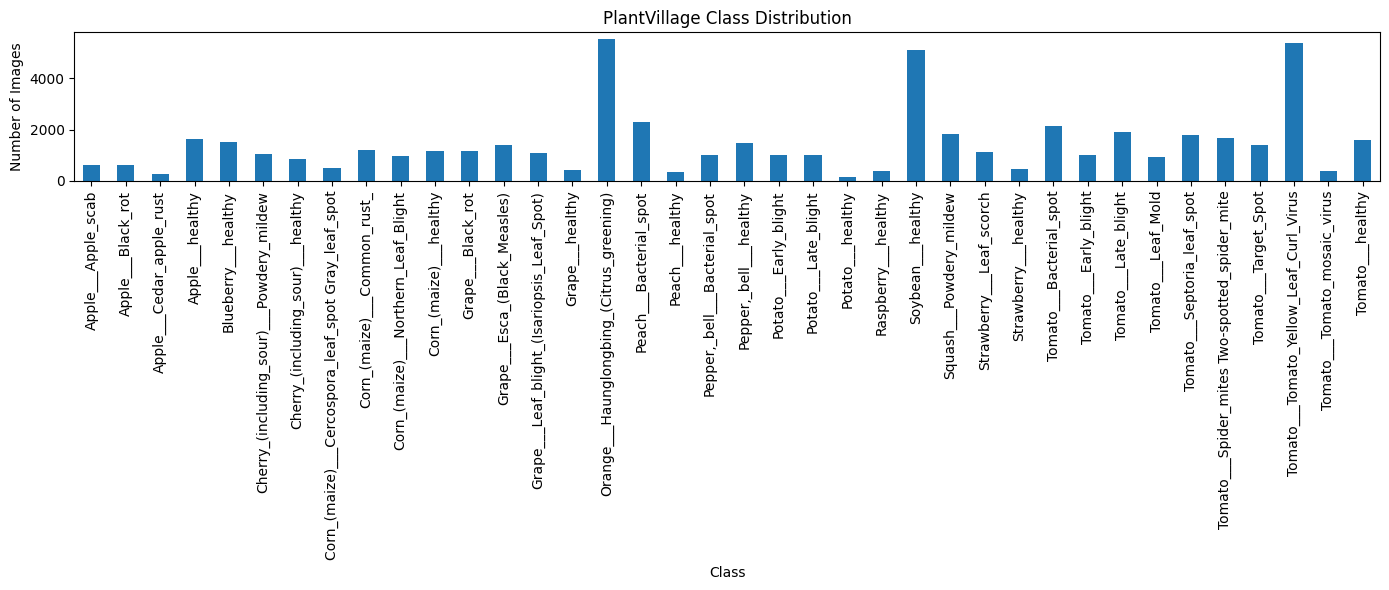

In [15]:
class_counts = df["class_name"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(14, 6))

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Class Distribution")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nPercentages:")

print("Train:", len(train_df) / len(df) * 100)
print("Val:", len(val_df) / len(df) * 100)
print("Test:", len(test_df) / len(df) * 100)

Training images: 38013
Validation images: 8146
Testing images: 8146

Percentages:
Train: 69.99907927446827
Val: 15.00046036276586
Test: 15.00046036276586


In [17]:
TRAIN_CSV = os.path.join(PROJECT_DIR, "train_split.csv")
VAL_CSV = os.path.join(PROJECT_DIR, "val_split.csv")
TEST_CSV = os.path.join(PROJECT_DIR, "test_split.csv")

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("Split files saved.")
print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

Split files saved.
/content/drive/MyDrive/PlantDisease_Model1/train_split.csv
/content/drive/MyDrive/PlantDisease_Model1/val_split.csv
/content/drive/MyDrive/PlantDisease_Model1/test_split.csv


In [18]:
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Validation ∩ Test:", len(val_paths & test_paths))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created.")

Transforms created.


In [20]:
class PlantVillageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["filepath"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
train_dataset = PlantVillageDataset(
    train_df,
    transform=train_transform
)

val_dataset = PlantVillageDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = PlantVillageDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 38013
Validation dataset: 8146
Test dataset: 8146


In [44]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created.")
print("Batch size:", BATCH_SIZE)

DataLoaders created.
Batch size: 64


In [23]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Device:", device)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Device: cuda


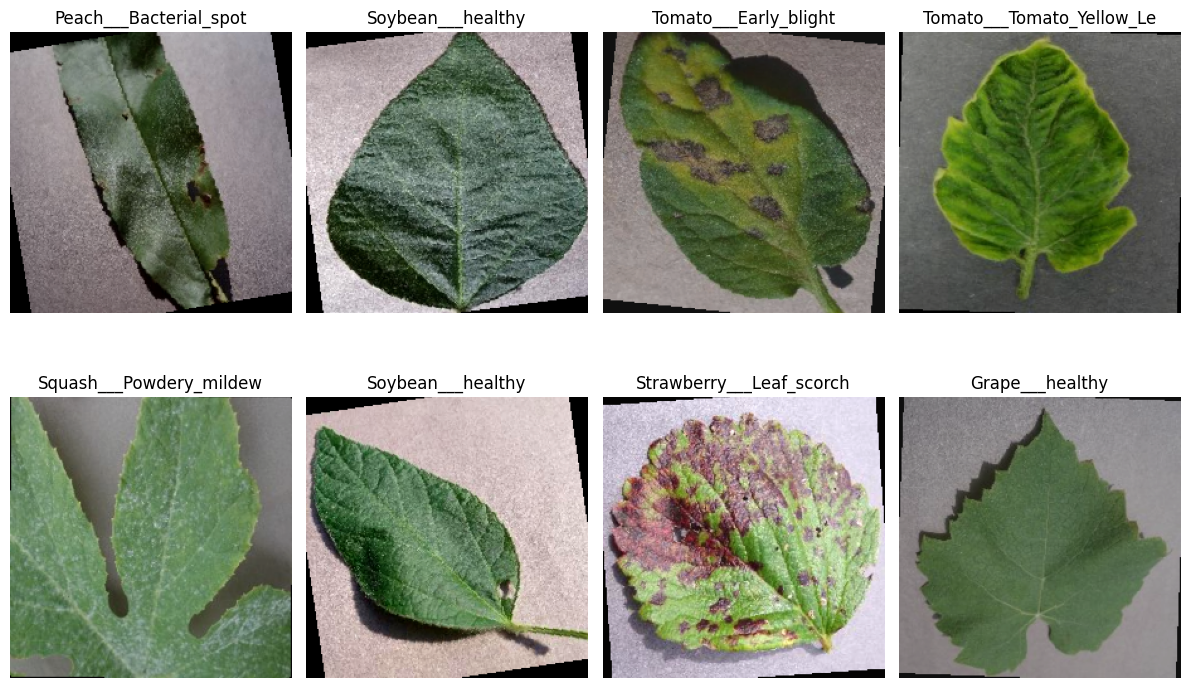

In [24]:
def denormalize(image):

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(image, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):

    image = denormalize(images[i]).permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(idx_to_class[int(labels[i])][:25])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden_channels = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(
                channels,
                hidden_channels,
                kernel_size=1,
                bias=False
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden_channels,
                channels,
                kernel_size=1,
                bias=False
            )
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_attention = self.mlp(self.avg_pool(x))
        max_attention = self.mlp(self.max_pool(x))

        attention = avg_attention + max_attention

        attention = self.sigmoid(attention)

        return x * attention

In [26]:
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_attention = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_attention, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        attention = torch.cat(
            [avg_attention, max_attention],
            dim=1
        )

        attention = self.conv(attention)
        attention = self.sigmoid(attention)

        return x * attention

In [27]:
class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.channel_attention = ChannelAttention(
            channels,
            reduction
        )

        self.spatial_attention = SpatialAttention(
            kernel_size=7
        )

    def forward(self, x):

        x = self.channel_attention(x)
        x = self.spatial_attention(x)

        return x

In [28]:
class GeM(nn.Module):

    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()

        self.p = nn.Parameter(
            torch.ones(1) * p
        )

        self.eps = eps

    def forward(self, x):

        x = x.clamp(min=self.eps)

        x = F.avg_pool2d(
            x.pow(self.p),
            kernel_size=(x.size(-2), x.size(-1))
        )

        x = x.pow(
            1.0 / self.p
        )

        return x

In [29]:
class ConvNeXtGeMCBAM(nn.Module):

    def __init__(
        self,
        num_classes=38,
        dropout=0.3
    ):

        super().__init__()

        self.backbone = models.convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.DEFAULT
        )

        self.attention = CBAM(
            channels=768,
            reduction=16
        )

        self.gem = GeM()

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Dropout(dropout),

            nn.Linear(
                768,
                num_classes
            )
        )

    def forward(self, x):

        x = self.backbone.features(x)

        x = self.attention(x)

        x = self.gem(x)

        x = self.classifier(x)

        return x

In [30]:
model = ConvNeXtGeMCBAM(
    num_classes=38,
    dropout=0.3
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 157MB/s]


ConvNeXtGeMCBAM(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm(

In [31]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 28,692,177
Trainable parameters: 28,692,177


In [32]:
sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(device)

with torch.no_grad():
    sample_output = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 38])


In [45]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

scaler = torch.amp.GradScaler("cuda")

print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Mixed precision enabled.")

Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Initial learning rate: 0.0001
Mixed precision enabled.


In [46]:
EPOCHS = 5
PATIENCE = 2

BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "model1_convnext_gem_cbam_best.pth"
)

LATEST_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "model1_convnext_gem_cbam_latest.pth"
)

print("Epochs:", EPOCHS)
print("Early stopping patience:", PATIENCE)

print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\nLatest checkpoint:")
print(LATEST_MODEL_PATH)

Epochs: 5
Early stopping patience: 2

Best checkpoint:
/content/drive/MyDrive/PlantDisease_Model1/model1_convnext_gem_cbam_best.pth

Latest checkpoint:
/content/drive/MyDrive/PlantDisease_Model1/model1_convnext_gem_cbam_latest.pth


In [47]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = (
        100.0 * correct / total
    )

    elapsed_time = (
        time.time() - start_time
    ) / 60

    return (
        epoch_loss,
        epoch_accuracy,
        elapsed_time
    )

In [48]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    epoch_loss = running_loss / total

    epoch_accuracy = (
        100.0 * correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy,
        all_labels,
        all_predictions
    )

In [40]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_epoch = 0
epochs_without_improvement = 0

print("Training variables initialized.")

Training variables initialized.


In [49]:
for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc, train_time = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Learning-rate scheduler
    # -------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # -------------------------
    # Store history
    # -------------------------
    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_acc
    )

    history["learning_rate"].append(
        current_lr
    )

    # -------------------------
    # Print results
    # -------------------------
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_acc:.2f}%"
    )

    print(
        f"Learning Rate: {current_lr:.6f}"
    )

    print(
        f"Time: {train_time:.2f} minutes"
    )

    # -------------------------
    # Save latest checkpoint
    # -------------------------
    latest_checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "history": history
    }

    torch.save(
        latest_checkpoint,
        LATEST_MODEL_PATH
    )

    print("✓ Latest checkpoint saved")

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        best_checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(
                model.state_dict()
            ),
            "optimizer_state_dict": copy.deepcopy(
                optimizer.state_dict()
            ),
            "scheduler_state_dict": copy.deepcopy(
                scheduler.state_dict()
            ),
            "scaler_state_dict": copy.deepcopy(
                scaler.state_dict()
            ),
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "history": history
        }

        torch.save(
            best_checkpoint,
            BEST_MODEL_PATH
        )

        print("✓ Best model saved to Google Drive")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

    # -------------------------
    # Early stopping
    # -------------------------
    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


print("\nTraining completed.")

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best epoch: {best_epoch}"
)


Epoch 1/5
Train Loss: 3.2574 | Train Accuracy: 20.79%
Val Loss: 2.9440 | Val Accuracy: 29.33%
Learning Rate: 0.000100
Time: 4.49 minutes
✓ Latest checkpoint saved
✓ Best model saved to Google Drive

Epoch 2/5
Train Loss: 2.5607 | Train Accuracy: 37.52%
Val Loss: 2.1626 | Val Accuracy: 48.38%
Learning Rate: 0.000100
Time: 4.57 minutes
✓ Latest checkpoint saved
✓ Best model saved to Google Drive

Epoch 3/5
Train Loss: 1.9822 | Train Accuracy: 52.16%
Val Loss: 1.7228 | Val Accuracy: 58.72%
Learning Rate: 0.000100
Time: 4.42 minutes
✓ Latest checkpoint saved
✓ Best model saved to Google Drive

Epoch 4/5
Train Loss: 1.6351 | Train Accuracy: 61.09%
Val Loss: 1.4304 | Val Accuracy: 67.14%
Learning Rate: 0.000100
Time: 4.40 minutes
✓ Latest checkpoint saved
✓ Best model saved to Google Drive

Epoch 5/5
Train Loss: 1.3953 | Train Accuracy: 67.03%
Val Loss: 1.2237 | Val Accuracy: 72.29%
Learning Rate: 0.000100
Time: 4.45 minutes
✓ Latest checkpoint saved
✓ Best model saved to Google Drive

Trai

In [50]:
print(
    "Best checkpoint exists:",
    os.path.exists(BEST_MODEL_PATH)
)

print(
    "Latest checkpoint exists:",
    os.path.exists(LATEST_MODEL_PATH)
)

if os.path.exists(BEST_MODEL_PATH):
    print(
        "Best checkpoint size:",
        round(
            os.path.getsize(BEST_MODEL_PATH) / (1024**2),
            2
        ),
        "MB"
    )

Best checkpoint exists: True
Latest checkpoint exists: True
Best checkpoint size: 110.32 MB


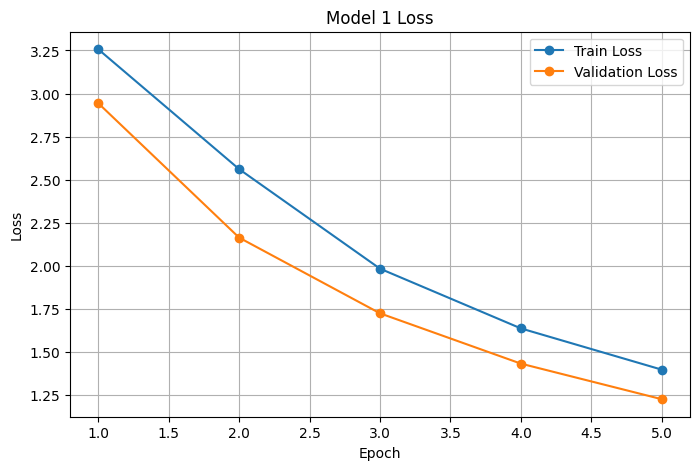

In [52]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 Loss")

plt.legend()
plt.grid(True)

plt.show()

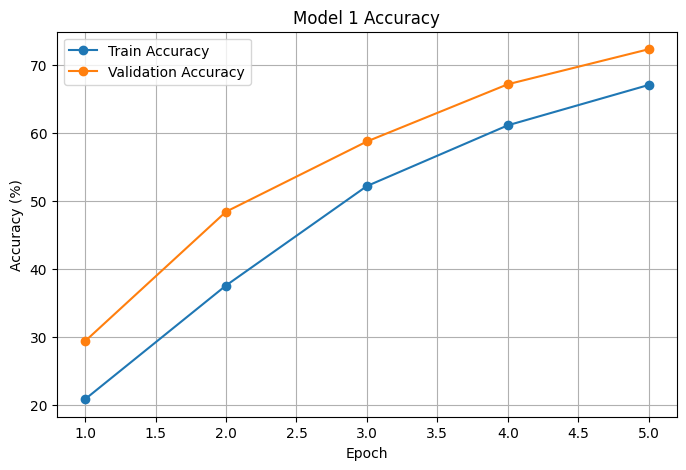

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Model 1 Accuracy")

plt.legend()
plt.grid(True)

plt.show()

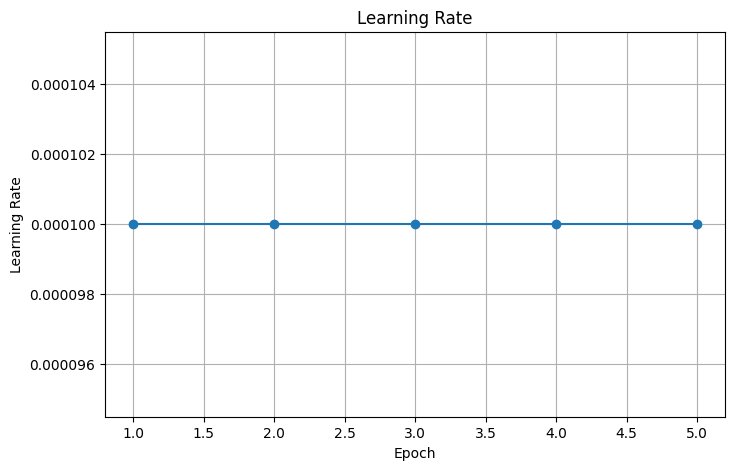

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["learning_rate"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate")

plt.grid(True)

plt.show()

In [55]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation accuracy:",
    checkpoint["val_accuracy"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

Best epoch: 5
Best validation accuracy: 72.29315001227596
Best validation loss: 1.2236809808090456


In [57]:
model.eval()

all_test_labels = []
all_test_predictions = []
all_test_probabilities = []

test_loss = 0.0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(
            dim=1
        )

        test_loss += (
            loss.item() * images.size(0)
        )

        test_total += labels.size(0)

        all_test_labels.extend(
            labels.cpu().numpy()
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_probabilities.extend(
            probabilities.cpu().numpy()
        )

test_loss = test_loss / test_total

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
) * 100

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Loss: 1.2224
Test Accuracy: 72.28%


In [58]:
precision = precision_score(
    all_test_labels,
    all_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_test_labels,
    all_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro",
    zero_division=0
)

print(
    f"Accuracy: {test_accuracy:.2f}%"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"Weighted F1: {f1:.4f}"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Accuracy: 72.28%
Precision: 0.6872
Recall: 0.7228
Weighted F1: 0.6774
Macro F1: 0.5081


In [59]:
report = classification_report(
    all_test_labels,
    all_test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.0000    0.0000    0.0000        94
                                 Apple___Black_rot     0.7191    0.6882    0.7033        93
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        41
                                   Apple___healthy     0.6019    0.7683    0.6750       246
                               Blueberry___healthy     0.6433    0.8540    0.7338       226
          Cherry_(including_sour)___Powdery_mildew     0.7727    0.6456    0.7034       158
                 Cherry_(including_sour)___healthy     0.9390    0.6016    0.7333       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.0000    0.0000    0.0000        77
                       Corn_(maize)___Common_rust_     0.8732    1.0000    0.9323       179
               Corn_(maize)___Northern_Leaf_Blight     0.6935    0.8776    0.77

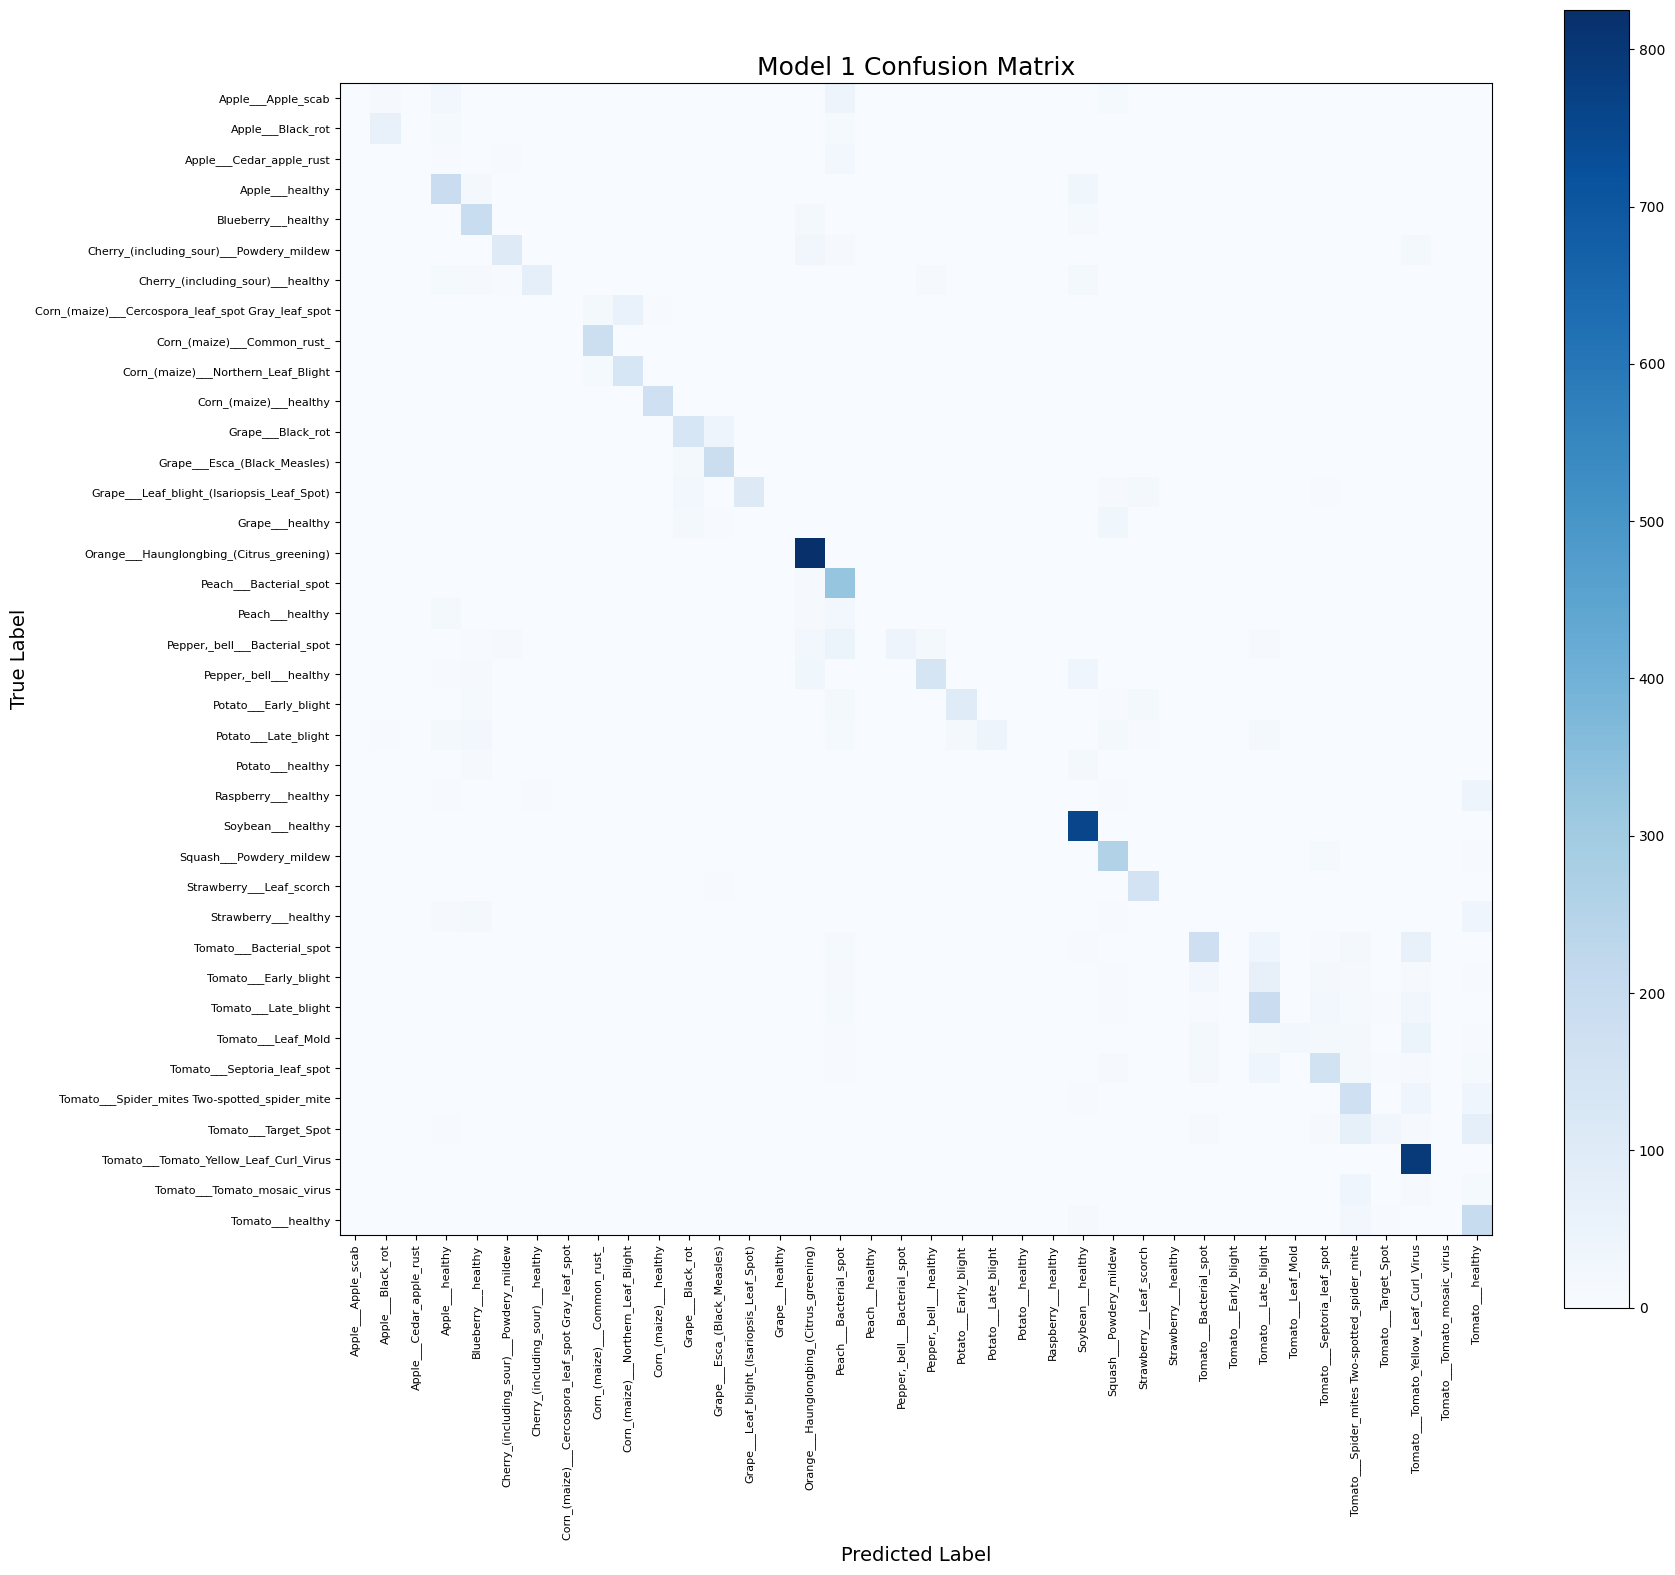

In [73]:
plt.figure(figsize=(18, 16))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title("Model 1 Confusion Matrix", fontsize=18)

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    tick_marks,
    class_names,
    fontsize=8
)

plt.xlabel(
    "Predicted Label",
    fontsize=14
)

plt.ylabel(
    "True Label",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [61]:
all_test_probabilities = np.array(
    all_test_probabilities
)

all_test_labels_np = np.array(
    all_test_labels
)

roc_auc = roc_auc_score(
    all_test_labels_np,
    all_test_probabilities,
    multi_class="ovr",
    average="macro"
)

print(
    f"Macro ROC-AUC: {roc_auc:.4f}"
)

Macro ROC-AUC: 0.9873


In [62]:
results = pd.DataFrame({
    "Model": ["Model 1"],
    "Architecture": [
        "ConvNeXt-Tiny + CBAM + GeM"
    ],
    "Input_Size": ["224x224"],
    "Classes": [38],
    "Best_Epoch": [
        checkpoint["epoch"]
    ],
    "Validation_Accuracy": [
        checkpoint["val_accuracy"]
    ],
    "Test_Accuracy": [
        test_accuracy
    ],
    "Precision": [
        precision
    ],
    "Recall": [
        recall
    ],
    "Weighted_F1": [
        f1
    ],
    "Macro_F1": [
        macro_f1
    ],
    "Macro_ROC_AUC": [
        roc_auc
    ]
})

RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "model1_results.csv"
)

results.to_csv(
    RESULTS_PATH,
    index=False
)

print(results)

print(
    "\nResults saved to:",
    RESULTS_PATH
)

     Model                Architecture Input_Size  Classes  Best_Epoch  \
0  Model 1  ConvNeXt-Tiny + CBAM + GeM    224x224       38           5   

   Validation_Accuracy  Test_Accuracy  Precision    Recall  Weighted_F1  \
0             72.29315      72.280874   0.687223  0.722809     0.677433   

   Macro_F1  Macro_ROC_AUC  
0  0.508056       0.987334  

Results saved to: /content/drive/MyDrive/PlantDisease_Model1/model1_results.csv


In [63]:
test_model = ConvNeXtGeMCBAM(
    num_classes=38,
    dropout=0.3
).to(device)

saved_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

test_model.load_state_dict(
    saved_checkpoint["model_state_dict"]
)

test_model.eval()

print("✓ Checkpoint successfully loaded.")
print(
    "Saved best epoch:",
    saved_checkpoint["epoch"]
)

del test_model

✓ Checkpoint successfully loaded.
Saved best epoch: 5


In [64]:
conv_layers = []

for name, module in model.named_modules():

    if isinstance(module, nn.Conv2d):
        conv_layers.append(
            (name, module)
        )

print(
    "Number of Conv2d layers:",
    len(conv_layers)
)

for name, layer in conv_layers[-10:]:
    print(name)

Number of Conv2d layers: 25
backbone.features.5.6.block.0
backbone.features.5.7.block.0
backbone.features.5.8.block.0
backbone.features.6.1
backbone.features.7.0.block.0
backbone.features.7.1.block.0
backbone.features.7.2.block.0
attention.channel_attention.mlp.0
attention.channel_attention.mlp.2
attention.spatial_attention.conv


In [65]:
target_layer_name, target_layer = conv_layers[-1]

print(
    "Grad-CAM target layer:"
)

print(target_layer_name)

print(target_layer)

Grad-CAM target layer:
attention.spatial_attention.conv
Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)


In [66]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self.save_activation
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self.save_gradient
            )
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate(
        self,
        image,
        class_idx=None
    ):

        self.model.zero_grad()

        output = self.model(image)

        if class_idx is None:
            class_idx = output.argmax(
                dim=1
            ).item()

        score = output[
            0,
            class_idx
        ]

        score.backward()

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return (
            cam.detach().cpu().numpy(),
            class_idx,
            output
            .detach()
            .cpu()
        )

    def remove_hooks(self):

        self.forward_handle.remove()
        self.backward_handle.remove()

In [67]:
gradcam = GradCAM(
    model,
    target_layer
)

print("Grad-CAM initialized.")

Grad-CAM initialized.


In [68]:
image, true_label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

print("True class:")
print(idx_to_class[int(true_label)])

print(
    "Input shape:",
    input_tensor.shape
)

True class:
Tomato___Late_blight
Input shape: torch.Size([1, 3, 224, 224])


In [69]:
cam, predicted_class, output = gradcam.generate(
    input_tensor
)

predicted_probability = torch.softmax(
    output,
    dim=1
)[0, predicted_class].item()

print(
    "True class:",
    idx_to_class[int(true_label)]
)

print(
    "Predicted class:",
    idx_to_class[predicted_class]
)

print(
    "Prediction confidence:",
    f"{predicted_probability * 100:.2f}%"
)

True class: Tomato___Late_blight
Predicted class: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Prediction confidence: 27.13%


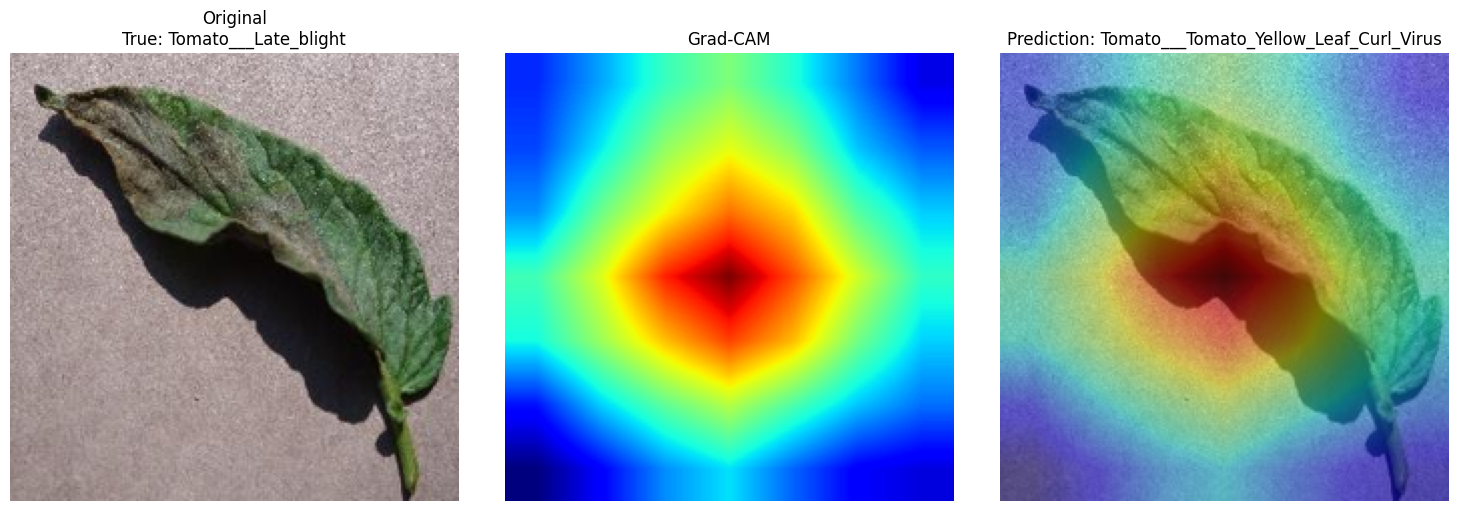

In [70]:
original_image = Image.open(
    test_df.iloc[0]["filepath"]
).convert("RGB")

original_image = original_image.resize(
    (224, 224)
)

original_array = np.array(
    original_image
) / 255.0

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)

plt.imshow(original_array)

plt.title(
    f"Original\n"
    f"True: {idx_to_class[int(true_label)]}"
)

plt.axis("off")


# Heatmap
plt.subplot(1, 3, 2)

plt.imshow(cam, cmap="jet")

plt.title("Grad-CAM")

plt.axis("off")


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(original_array)

plt.imshow(
    cam,
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"Prediction: "
    f"{idx_to_class[predicted_class]}"
)

plt.axis("off")

plt.tight_layout()

plt.show()

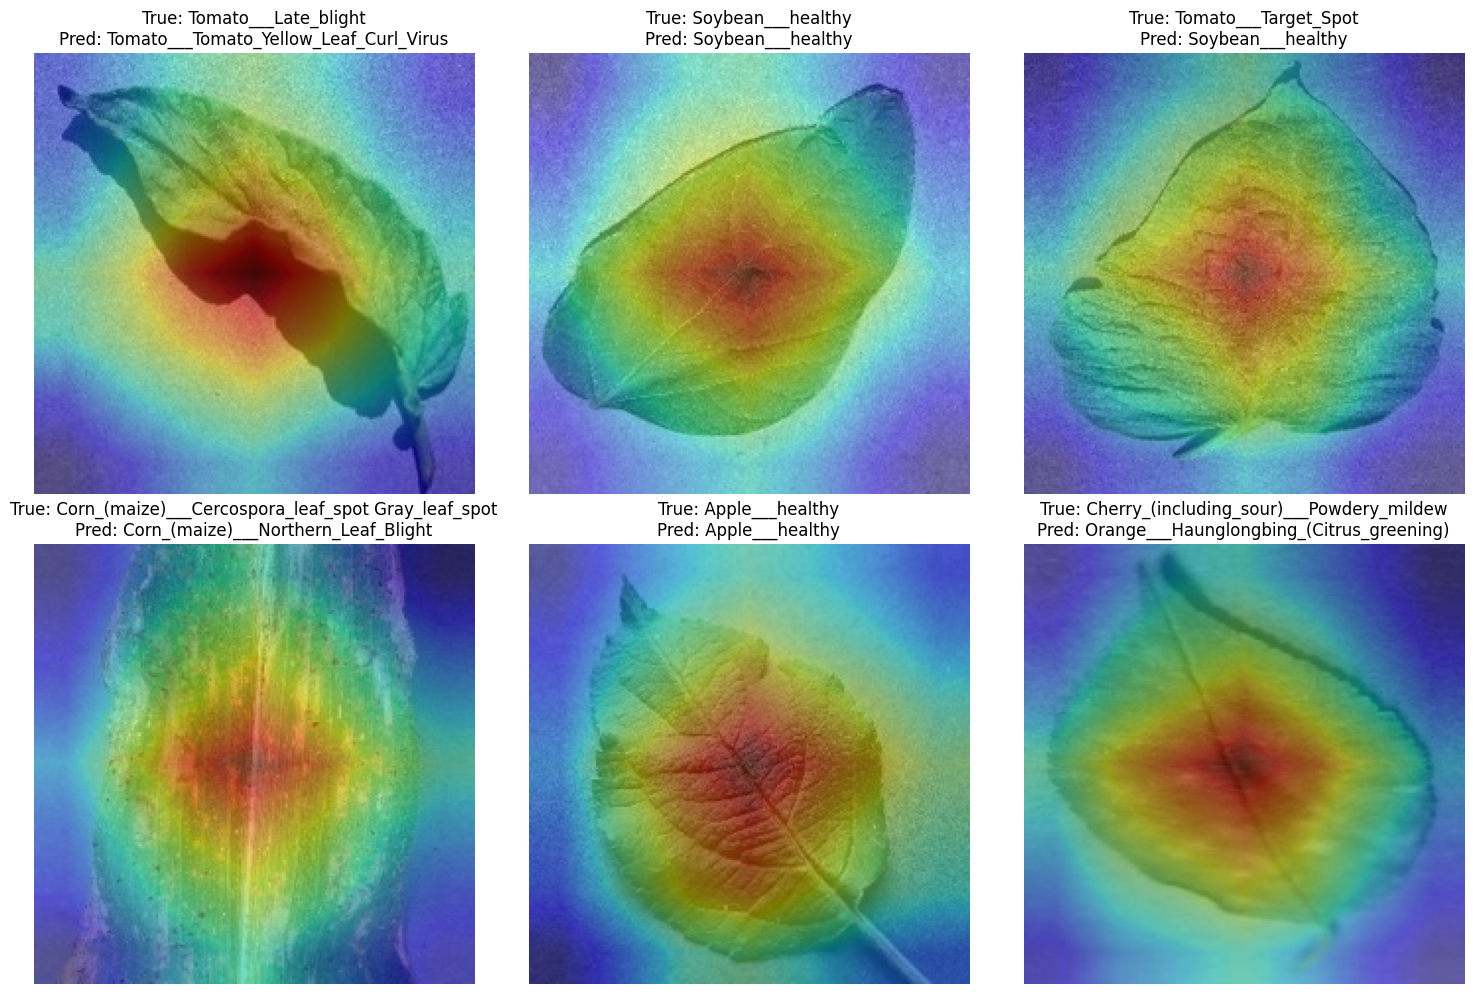

In [71]:
num_images = 6

plt.figure(figsize=(15, 10))

for i in range(num_images):

    image, true_label = test_dataset[i]

    input_tensor = (
        image.unsqueeze(0)
        .to(device)
    )

    cam, predicted_class, output = (
        gradcam.generate(input_tensor)
    )

    original = Image.open(
        test_df.iloc[i]["filepath"]
    ).convert("RGB")

    original = original.resize(
        (224, 224)
    )

    original = np.array(
        original
    ) / 255.0

    plt.subplot(2, 3, i + 1)

    plt.imshow(original)

    plt.imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )

    plt.title(
        "True: "
        + idx_to_class[int(true_label)]
        + "\nPred: "
        + idx_to_class[predicted_class]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
gradcam.remove_hooks()

print("Grad-CAM hooks removed.")

Grad-CAM hooks removed.
